In [1]:
%load_ext autoreload
%autoreload 2

import glob
import os
import pynwb
import graph
from tqdm import tqdm
from pathlib import Path 
from itertools import combinations
import itertools

import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
import scipy.stats as stats
import networkx as nx
from scipy.special import softmax


import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
pio.renderers.default = "notebook"   # or "notebook_connected" for interactive mode


In [3]:
# successor representation, with the assumption that the animal knows the model, but it is affected by the recent policy

# initialize M, expected occupancy matrix from the model

T

array([[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0]])

In [10]:
n = 4
T = np.zeros((16, 16), dtype=int)

# define actions as 0-left, 1-right, 2-up, 3-down

# MATLAB is 1-indexed, Python is 0-indexed
T[0, 1] = 1
T[1, 2] = 1
T[1, 5] = 1
T[2, 3] = 1
T[3, 7] = 1
T[4, 8] = 1
T[5, 6] = 1
T[5, 9] = 1
T[6, 7] = 1
T[6, 10] = 1
T[7, 11] = 1
T[8, 9] = 1
T[8, 12] = 1
T[9, 10] = 1
T[9, 13] = 1
T[10, 14] = 1
T[13, 14] = 1
T[14, 15] = 1

# Make symmetric
T = T + T.T

# Ensure binary
T[T > 0] = 1

In [ ]:
T_sa = np.zeros((16,4,16))



In [5]:
def create_grid(nr, nc, actions=['up','down','left','right'], barriers=None, teleports=None):

    if barriers is None:
        barriers = []
    if teleports is None:
        teleports = []

    barriers = set(barriers)

    S = nr * nc
    A = len(actions)

    T = np.zeros((S, A, S))

    def to_state(r, c):
        return r * nc + c

    def to_coord(s):
        return divmod(s, nc)

    action_map = {
        "up":    (-1, 0),
        "down":  (1, 0),
        "left":  (0, -1),
        "right": (0, 1),
    }

    for s in range(S):

        # If this state is a barrier → no transitions at all
        if s in barriers:
            continue

        r, c = to_coord(s)

        for a_idx, a in enumerate(actions):

            dr, dc = action_map[a]
            r2, c2 = r + dr, c + dc

            # boundary check
            if not (0 <= r2 < nr and 0 <= c2 < nc):
                continue

            s2 = to_state(r2, c2)

            # if next state is barrier → no transition
            if s2 in barriers:
                continue

            T[s, a_idx, s2] = 1

    # teleports (only if both ends are non-barrier)
    for (s_from, s_to) in teleports:
        if s_from not in barriers and s_to not in barriers:
            for a in range(A):
                T[s_from, a, :] = 0
                T[s_from, a, s_to] = 1

    return T


In [3]:
def multi_reward_distance_value(T_adj, reward_dict, gamma, barriers=None):
    """
    T_adj: adjacency matrix (S x S)
    reward_dict: {state_index: reward_value}
    gamma: discount factor
    """
    
    G = nx.from_numpy_array(T_adj)
    S = T_adj.shape[0]
    V = np.zeros(S)

    for r_state, r_value in reward_dict.items():
        dist = nx.single_source_shortest_path_length(G, r_state)
        for s, d in dist.items():
            val = (gamma ** d) * r_value
            V[s] = max(V[s], val)

    if barriers is None:
        barriers = []
    for s in range(S):
        if s in barriers:
            V[s] = np.nan
    
    return V


In [18]:
def compute_policy_from_value(V, nr, nc, barriers=None, beta=10.0):
    """
    V: flat value vector (n*n,)
    n: grid size
    beta: inverse temperature
    """
    
    policy = np.zeros((nr, nc, 4))  # up, left, right, down
    if barriers is None:
        barriers = []
        
    def to_state(i, j):
        return i * nc + j
    
    for i in range(nr):
        for j in range(nc):
            
            s = to_state(i, j)

            if s in barriers:
                policy[i, j] = np.zeros(4)*np.nan

            else:
                    
                action_values = np.full(4, -np.nan)
                
                # up
                if i > 0:
                    s2 = to_state(i-1, j)
                    action_values[0] = V[s2]
                    
                # left
                if j > 0:
                    s2 = to_state(i, j-1)
                    action_values[1] = V[s2]
                    
                # right
                if j < nc-1:
                    s2 = to_state(i, j+1)
                    action_values[2] = V[s2]
                    
                # down
                if i < nr-1:
                    s2 = to_state(i+1, j)
                    action_values[3] = V[s2]
                
                # softmax over valid neighbors
                valid = ~np.isnan(action_values) 
                probs = np.zeros(4)
                probs[valid] = softmax(beta * action_values[valid])
                
                policy[i, j] = probs

    return policy


In [218]:
# define reward location and magnitude

msize = 13
offset = 3

reward_dict={}
magnitudes = [2,8,8,2]

idx = 0
for ii in [offset,msize-offset-1]:
    for jj in [offset,msize-offset-1]:
        reward_dict[ii*msize+jj] = magnitudes[idx]
        idx=idx+1




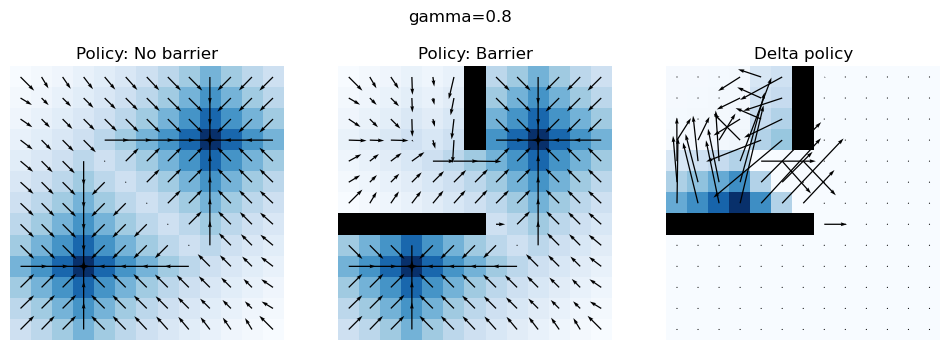

In [222]:
gamma = 0.8
beta = 3

fig, axes = plt.subplots(1,3,figsize=(12,4))

# no barrier
T = create_grid(msize, barriers=None)
V = multi_reward_distance_value(T.sum(axis=1)>0, reward_dict, gamma)
policy = compute_policy_from_value(V, msize, beta=beta)
plot_value_policy(V.reshape(msize,msize), policy, axes[0], 'Policy: No barrier',scale=10)


# with barrier
# door = np.array([0,1,2])
# barriers = np.arange(msize*7,msize*8)[~np.isin(np.arange(msize),door)]
barriers = np.concat([np.arange(msize*7,msize*7+7),np.arange(6,msize*4+6,msize)])
T_barrier = create_grid(msize, barriers=barriers)
V_barrier = multi_reward_distance_value(T_barrier.sum(axis=1)>0, reward_dict, gamma, barriers=barriers)
policy_barrier = compute_policy_from_value(V_barrier, msize, barriers=barriers, beta=beta)

plot_value_policy(V_barrier.reshape(msize,msize), policy_barrier, axes[1], 'Policy: Barrier',scale=10)


# change in policy
plot_value_policy((V_barrier-V).reshape(msize,msize), policy_barrier-policy, axes[2], 'Delta policy',
                  map_color='Blues_r', vector_color='k',scale=4)

# change in goal
plt.suptitle(f'gamma={gamma}')
plt.savefig(f'Barrier and change in policy 3')

Text(0.5, 0.98, 'gamma=0.8')

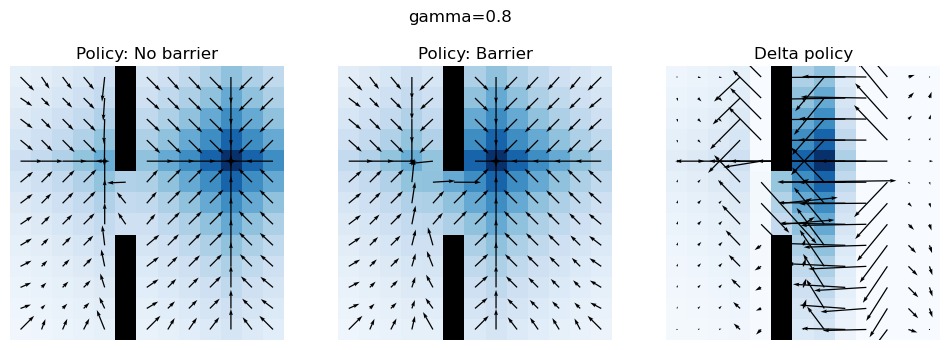

In [11]:
# creating room and door, same transition model, change reward locations

msize = 13
offset = 3
gamma = 0.8
beta = 3

door = np.array([5,6,7])
barriers = np.arange(5,msize*msize+5,msize)[~np.isin(np.arange(msize),door)]
T = create_grid(msize, barriers=barriers)

# barriers = np.concat([np.arange(msize*7,msize*7+7),np.arange(6,msize*4+6,msize)])

fig, axes = plt.subplots(1,3,figsize=(12,4))

# reward 1
reward_dict={4*msize+4: 4,
            4*msize+10: 8}
V1 = multi_reward_distance_value(T.sum(axis=1)>0, reward_dict, gamma, barriers=barriers)
policy1 = compute_policy_from_value(V1, msize, barriers=barriers, beta=beta)
plot_value_policy(V1.reshape(msize,msize), policy1, axes[0], 'Policy: No barrier',scale=10)


# reward 2
reward_dict={4*msize+3: 4,
            4*msize+7: 8}

V2 = multi_reward_distance_value(T.sum(axis=1)>0, reward_dict, gamma, barriers=barriers)
policy2 = compute_policy_from_value(V2, msize, barriers=barriers, beta=beta)
plot_value_policy(V2.reshape(msize,msize), policy2, axes[1], 'Policy: Barrier',scale=10)

# change in policy
plot_value_policy((V2-V1).reshape(msize,msize), policy2-policy1, axes[2], 'Delta policy',
                  map_color='Blues', vector_color='k',scale=4)

# change in goal
plt.suptitle(f'gamma={gamma}')
# plt.savefig(f'Barrier and change in policy 3')

In [34]:
policy1.shape

(5, 10, 4)

In [65]:
def plot_value_policy(V, policy, ax, title, map_color='Blues', vector_color='k', scale=1):

    nr = policy.shape[0]
    nc = policy.shape[1]
    
    x = np.arange(nc)
    y = np.arange(nr)
    X, Y = np.meshgrid(x, y)
    
    # Policy-derived vector field
    dY = policy[:, :, 0] - policy[:, :, 3]
    dX = policy[:, :, 2] - policy[:, :, 1]


    # ---- Heatmap ----

    cmap = plt.get_cmap(map_color).copy()
    cmap.set_bad(color='k')
    
    im = ax.imshow(
        V,
        origin='lower',        # important so (0,0) is bottom-left
        extent=[-0.5, nc-0.5, -0.5, nr-0.5],
        cmap=cmap,
        vmin=0
    )
    
    # plt.colorbar(im, ax=ax, label="Value")

    print(X.shape)
    # ---- Quiver ----
    ax.quiver(X, Y, dX, dY, color=vector_color, scale=scale)
    
    ax.set_xticks(np.arange(nc))
    ax.set_yticks(np.arange(nr))
    ax.set_xlim(-0.5, nc-0.5)
    ax.set_ylim(-0.5, nr-0.5)
    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.axis("off")

    ax.set_title(title, fontsize=18)


(9, 19)
(9, 19)
(9, 19)


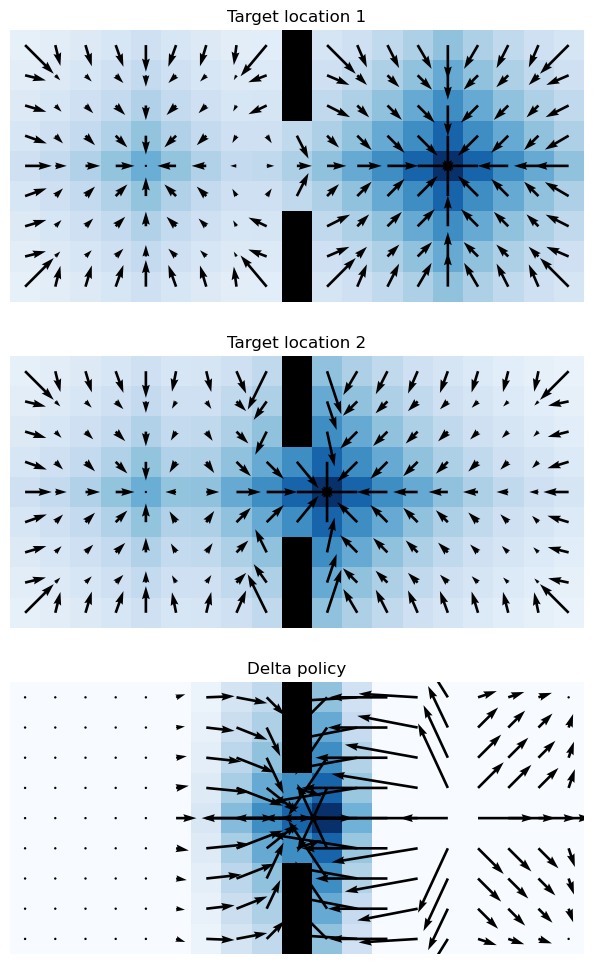

In [57]:
nr = 9
nc = 19

door = np.array([3,4,5])
barriers = np.arange(9,nr*nc+9,nc)[~np.isin(np.arange(nr),door)]
T = create_grid(nr,nc,barriers=barriers)

fig, axes = plt.subplots(3,1,figsize=(8,12))

# reward 1

reward_dict={4*nc+4: 1,
            5*nc-5: 2}
V1 = multi_reward_distance_value(T.sum(axis=1)>0, reward_dict, gamma,  barriers=barriers)
policy1 = compute_policy_from_value(V1, nr, nc, barriers=barriers, beta=beta)
plot_value_policy(V1.reshape(nr,nc), policy1, axes[0], 'Target location 1',scale=10)


# reward 2

reward_dict={4*nc+4: 1,
            5*nc-9: 2}
V2 = multi_reward_distance_value(T.sum(axis=1)>0, reward_dict, gamma,  barriers=barriers)
policy2 = compute_policy_from_value(V2, nr, nc, barriers=barriers, beta=beta)
plot_value_policy(V2.reshape(nr,nc), policy2, axes[1], 'Target location 2',scale=10)


# change in policy
plot_value_policy((V2-V1).reshape(nr,nc), policy2-policy1, axes[2], 'Delta policy',
                  map_color='Blues', vector_color='k',scale=4)

(9, 19)
(9, 19)
(9, 19)


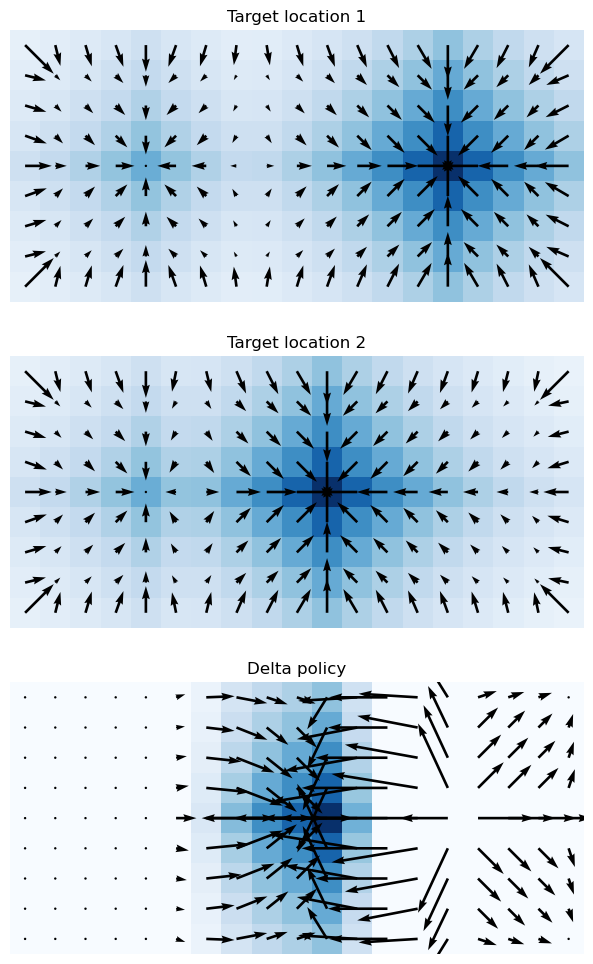

In [60]:
nr = 9
nc = 19

# no barrier
T = create_grid(nr,nc)

fig, axes = plt.subplots(3,1,figsize=(8,12))

# reward 1

reward_dict={4*nc+4: 1,
            5*nc-5: 2}
V1 = multi_reward_distance_value(T.sum(axis=1)>0, reward_dict, gamma)
policy1 = compute_policy_from_value(V1, nr, nc, beta=beta)
plot_value_policy(V1.reshape(nr,nc), policy1, axes[0], 'Target location 1',scale=10)


# reward 2

reward_dict={4*nc+4: 1,
            5*nc-9: 2}
V2 = multi_reward_distance_value(T.sum(axis=1)>0, reward_dict, gamma)
policy2 = compute_policy_from_value(V2, nr, nc, beta=beta)
plot_value_policy(V2.reshape(nr,nc), policy2, axes[1], 'Target location 2',scale=10)


# change in policy
plot_value_policy((V2-V1).reshape(nr,nc), policy2-policy1, axes[2], 'Delta policy',
                  map_color='Blues', vector_color='k',scale=4)

(11, 11)
(11, 11)
(11, 11)


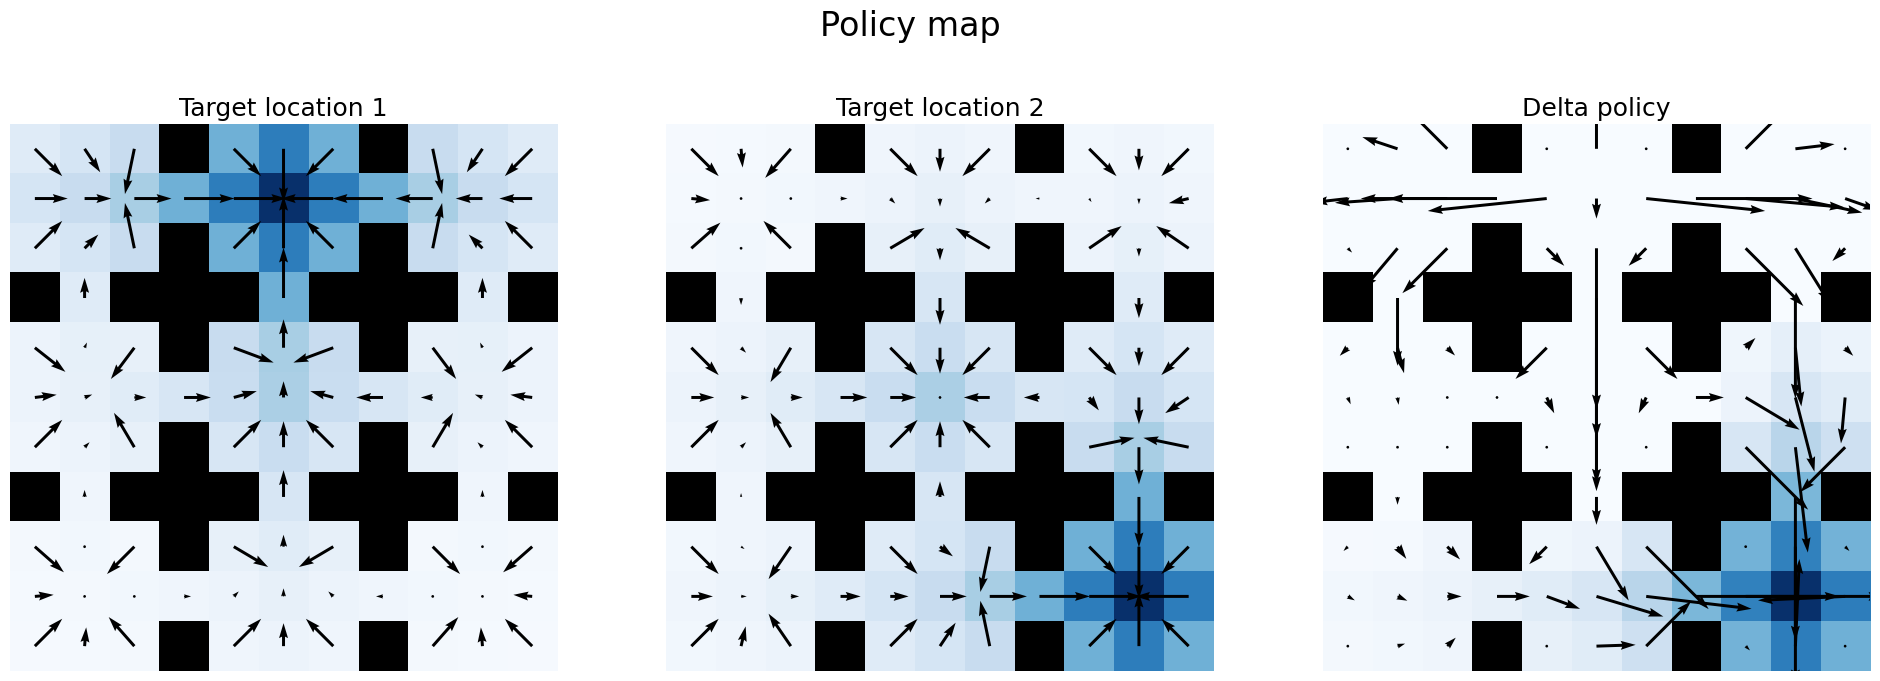

In [95]:
nr = 11
nc = 11
gamma = 0.7
beta = 3

barriers = []
door = np.array([1,5,9])
for ii in [3,7]:
    barriers.append(np.arange(ii,nr*nc+ii,nc)[~np.isin(np.arange(nr),door)])
for ii in [3,7]:
    barriers.append(np.arange(ii*nc,(ii+1)*nc)[~np.isin(np.arange(nr),door)])  
barriers = np.concat(barriers)

T = create_grid(nr,nc,barriers=barriers)


fig, axes = plt.subplots(1,3,figsize=(24,8))

# reward 1

reward_dict={5*nc+5: 1,
            1*nc+5: 3}
V1 = multi_reward_distance_value(T.sum(axis=1)>0, reward_dict, gamma,barriers=barriers)
policy1 = compute_policy_from_value(V1, nr, nc, barriers=barriers,beta=beta)
plot_value_policy(V1.reshape(nr,nc), policy1, axes[0], 'Target location 1',scale=10)


# reward 2

reward_dict={5*nc+5: 1,
            9*nc+9: 3}
V2 = multi_reward_distance_value(T.sum(axis=1)>0, reward_dict, gamma,barriers=barriers)
policy2 = compute_policy_from_value(V2, nr, nc,barriers=barriers, beta=beta)
plot_value_policy(V2.reshape(nr,nc), policy2, axes[1], 'Target location 2',scale=10)


# change in policy
plot_value_policy((V2-V1).reshape(nr,nc), policy2-policy1, axes[2], 'Delta policy',
                  map_color='Blues', vector_color='k',scale=4)
plt.suptitle('Policy map',fontsize=24)
plt.savefig('Change reward location, rooms')

(9, 9)
(9, 9)
(9, 9)


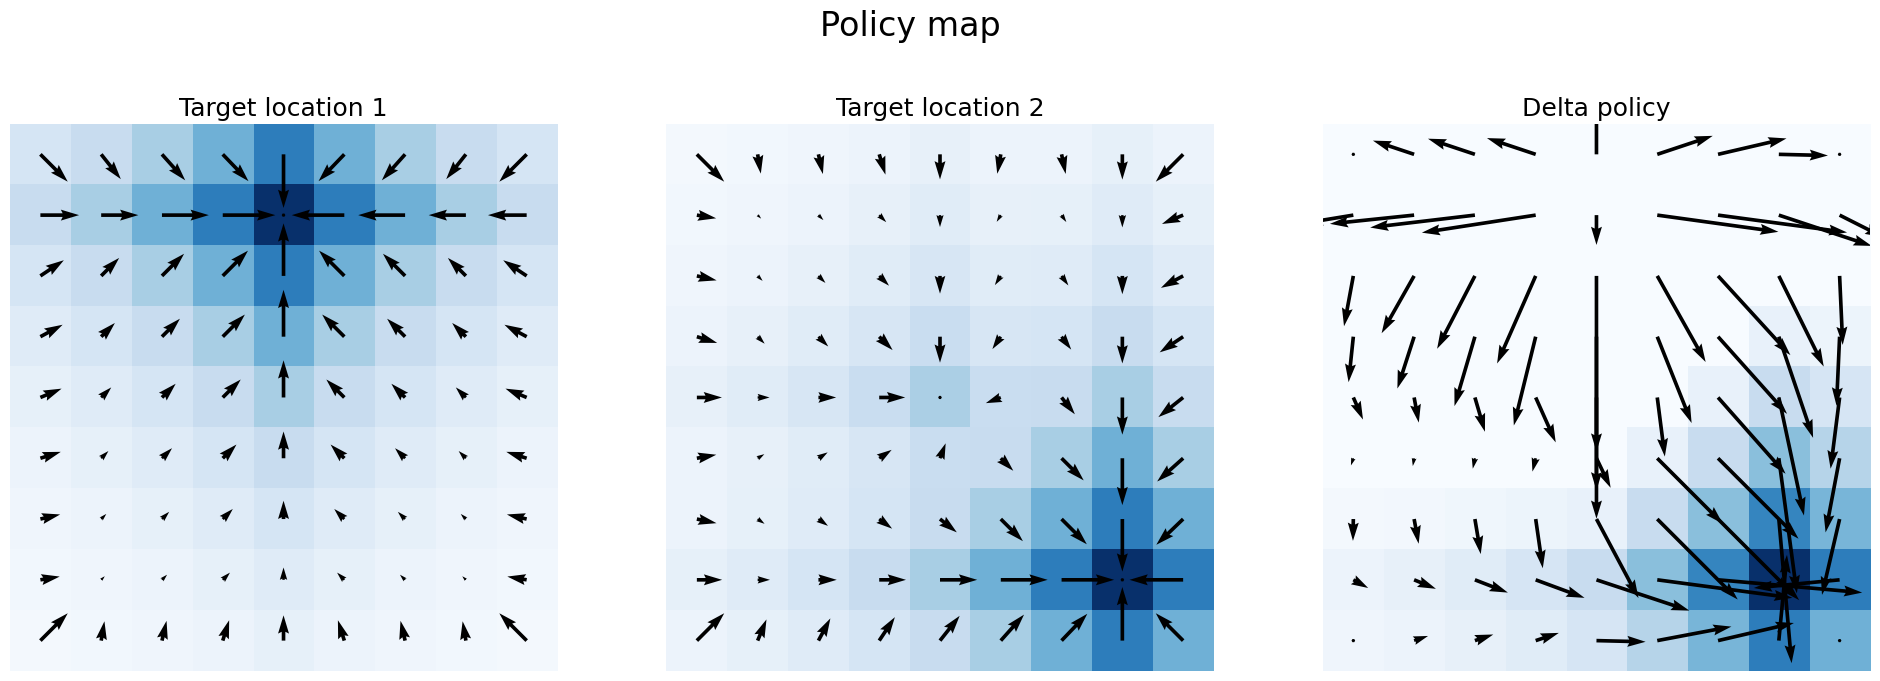

In [96]:
# with walls
nr = 9
nc = 9
gamma = 0.7
beta = 3

# no barrier
T = create_grid(nr,nc)

fig, axes = plt.subplots(1,3,figsize=(24,8))

# reward 1

reward_dict={4*nc+4: 1,
            1*nc+4: 3}
V1 = multi_reward_distance_value(T.sum(axis=1)>0, reward_dict, gamma)
policy1 = compute_policy_from_value(V1, nr, nc, beta=beta)
plot_value_policy(V1.reshape(nr,nc), policy1, axes[0], 'Target location 1',scale=10)


# reward 2

reward_dict={4*nc+4: 1,
            7*nc+7: 3}
V2 = multi_reward_distance_value(T.sum(axis=1)>0, reward_dict, gamma)
policy2 = compute_policy_from_value(V2, nr, nc, beta=beta)
plot_value_policy(V2.reshape(nr,nc), policy2, axes[1], 'Target location 2',scale=10)


# change in policy
plot_value_policy((V2-V1).reshape(nr,nc), policy2-policy1, axes[2], 'Delta policy',
                  map_color='Blues', vector_color='k',scale=4)
plt.suptitle('Policy map',fontsize=24)
plt.savefig('Change reward location')

In [40]:
policy1.shape

(5, 10, 4)

In [15]:
# list all possible combinations of reward size * reward location

arr = [1,1,2,3]
perms = set(itertools.permutations(arr))
perms = np.array(list(perms))

duplicates = []
idx = np.where(perms[:,0]>1)[0]
for ii in idx:
    perm_ = perms[ii,:]
    for jj in range(len(perms)):
        if np.array_equal(perm_, perms[jj,::-1]):
            duplicates.append(ii)

no_dup = perms[duplicates,:]

In [5]:
target_params = np.array([[2,2,2],
                         [2,6,2],
                         [6,2,4],
                         [6,6,8]])

# Suppose these are your value_map outputs
# Replace these with your actual function calls
X1, Y1, Z1 = value_map(9, target_params, gamma=0.6)
barriers1 = []
for ii in range(9):
    barriers1.append([4*9+ii,5*9+ii])
X2, Y2, Z2 = value_map(9, target_params, gamma=0.6, barriers=barriers1)
barriers2 = []
for ii in range(9):
    barriers2.append([ii*9+4,ii*9+5])
X3, Y3, Z3 = value_map(9, target_params, gamma=0.6, barriers=barriers2)

# Create a 1x3 subplot layout for 3D plots
fig = make_subplots(
    rows=1, cols=3,
    specs=[[{'type': 'surface'}, {'type': 'surface'}, {'type': 'surface'}]],
    subplot_titles=("Surface 1", "Surface 2", "Surface 3")
)

# Add the three surface plots
fig.add_trace(go.Surface(z=Z1, x=X1, y=Y1, colorscale='Viridis'), row=1, col=1)
fig.add_trace(go.Surface(z=Z2, x=X2, y=Y2, colorscale='Viridis'), row=1, col=2)
fig.add_trace(go.Surface(z=Z3, x=X3, y=Y3, colorscale='Viridis'), row=1, col=3)

# Layout adjustments
fig.update_layout(
    title="Three 3D Surface Plots Side by Side",
    width=1200, height=400
)


pio.renderers.default = "notebook_connected"
fig.show()


map disconnected
map disconnected


In [8]:
target_params = np.array([[2,2,2],
                         [2,6,4],
                         [6,2,8],
                         [6,6,2]])

# Suppose these are your value_map outputs
# Replace these with your actual function calls
X1, Y1, Z1 = value_map(9, target_params, gamma=0.6)
barriers1 = []
for ii in range(9):
    barriers1.append([4*9+ii,5*9+ii])
X2, Y2, Z2 = value_map(9, target_params, gamma=0.6, barriers=barriers1)
barriers2 = []
for ii in range(9):
    barriers2.append([ii*9+4,ii*9+5])
X3, Y3, Z3 = value_map(9, target_params, gamma=0.6, barriers=barriers2)

# Create a 1x3 subplot layout for 3D plots
fig = make_subplots(
    rows=1, cols=3,
    specs=[[{'type': 'surface'}, {'type': 'surface'}, {'type': 'surface'}]],
    subplot_titles=("Surface 1", "Surface 2", "Surface 3")
)

# Add the three surface plots
fig.add_trace(go.Surface(z=Z1, x=X1, y=Y1, colorscale='Viridis'), row=1, col=1)
fig.add_trace(go.Surface(z=Z2, x=X2, y=Y2, colorscale='Viridis'), row=1, col=2)
fig.add_trace(go.Surface(z=Z3, x=X3, y=Y3, colorscale='Viridis'), row=1, col=3)

# Layout adjustments
fig.update_layout(
    title="Three 3D Surface Plots Side by Side",
    width=1200, height=400
)


pio.renderers.default = "notebook_connected"
fig.show()


map disconnected
map disconnected
